# 9)Breast Cancer Analysis and Naïve Bayes Classification Using the Breast_Cancer.csv dataset: 1. Perform basic EDA by displaying the first five records, missing values, descriptive statistics, and diagnosis distribution. 2. Plot a scatter plot of radius_mean vs texture_mean, a histogram of radius_mean, and a box plot of radius_mean by diagnosis. 3. Apply Gaussian Naïve Bayes to predict diagnosis using the numerical features, with an 80:20 train-test split. 4. Display the classification report and accuracy.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import LabelEncoder

In [ ]:
df = pd.read_csv("/Cancer_Data - Cancer_Data.csv")

# Display first five records
print("First Five Records:")
print(df.head())

# Check missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Descriptive statistics
print("\nDescriptive Statistics:")
print(df.describe())

# Diagnosis distribution
print("\nDiagnosis Distribution:")
print(df["diagnosis"].value_counts())

First Five Records:
         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   ...  radius_worst  texture_worst  perim

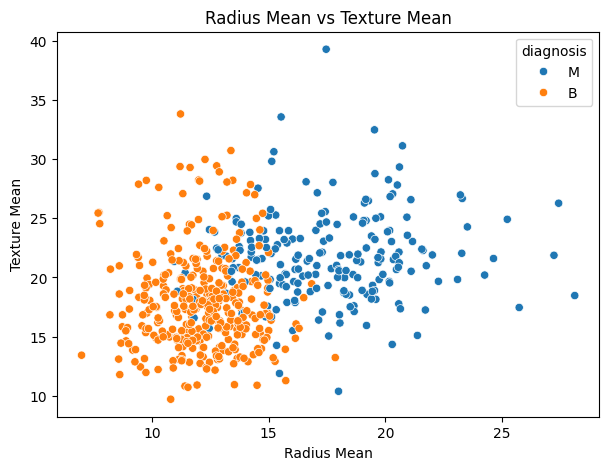

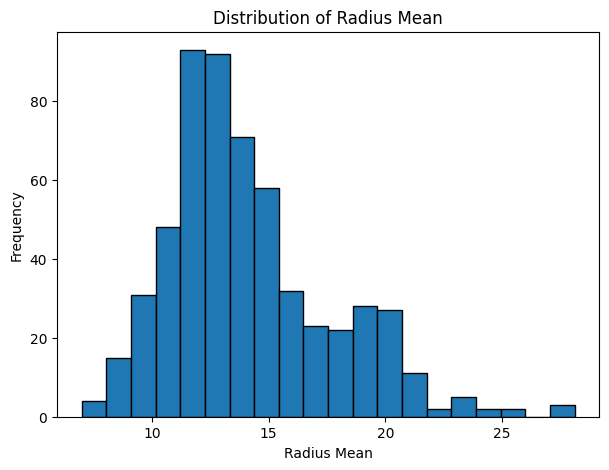

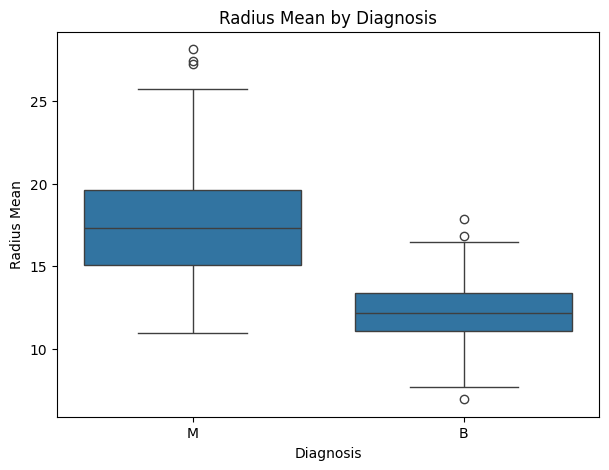

In [ ]:
# 2)Scatter plot: radius_mean vs texture_mean
plt.figure(figsize=(7, 5))
sns.scatterplot(
    data=df,
    x="radius_mean",
    y="texture_mean",
    hue="diagnosis"
)
plt.title("Radius Mean vs Texture Mean")
plt.xlabel("Radius Mean")
plt.ylabel("Texture Mean")
plt.show()


# Histogram of radius_mean
plt.figure(figsize=(7, 5))
plt.hist(df["radius_mean"], bins=20, edgecolor="black")
plt.title("Distribution of Radius Mean")
plt.xlabel("Radius Mean")
plt.ylabel("Frequency")
plt.show()


# Box plot of radius_mean by diagnosis
plt.figure(figsize=(7, 5))
sns.boxplot(
    data=df,
    x="diagnosis",
    y="radius_mean"
)
plt.title("Radius Mean by Diagnosis")
plt.xlabel("Diagnosis")
plt.ylabel("Radius Mean")
plt.show()


In [ ]:
# 3)Remove unnecessary column if present
# 'id' is not a useful numerical feature for classification
if "id" in df.columns:
    df = df.drop("id", axis=1)

# Separate features and target
X = df.drop("diagnosis", axis=1)
y = df["diagnosis"]

# Keep only numerical features
X = X.select_dtypes(include=["number"])

# Encode diagnosis
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)

# 80:20 train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Create Gaussian Naïve Bayes model
model = GaussianNB()

# Train model
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)


In [ ]:
#4)
print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=label_encoder.classes_
    )
)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy Percentage:", accuracy * 100, "%")


Classification Report:
              precision    recall  f1-score   support

           B       0.91      1.00      0.95        72
           M       1.00      0.83      0.91        42

    accuracy                           0.94       114
   macro avg       0.96      0.92      0.93       114
weighted avg       0.94      0.94      0.94       114

Accuracy: 0.9385964912280702
Accuracy Percentage: 93.85964912280701 %


# 10)Iris Flower Analysis and Naïve Bayes Classification
Using the Iris.csv dataset:
1. Perform basic EDA by displaying the first five records, missing values,
descriptive statistics, and species distribution.
2. Plot a scatter plot of Sepal Length vs Sepal Width, a histogram of Sepal
Length, and a box plot of Sepal Length by Species.
3. Apply Gaussian Naïve Bayes to predict Species using the numerical features,
with an 80:20 train-test split.
# 4. Display the classification report and accuracy

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, accuracy_score

In [ ]:
df = pd.read_csv("/Iris - Iris.csv")

# Display first five records
print("First Five Records:")
print(df.head())


# Check missing values
print("\nMissing Values:")
print(df.isnull().sum())


# Descriptive statistics
print("\nDescriptive Statistics:")
print(df.describe())


# Species distribution
print("\nSpecies Distribution:")
print(df["Species"].value_counts())

First Five Records:
   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa

Missing Values:
Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

Descriptive Statistics:
               Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
count  150.000000     150.000000    150.000000     150.000000    150.000000
mean    75.500000       5.843333      3.054000       3.758667      1.198667
std     43.445368       0.828066      0.433594       1.764420      0.763161
min      1.000000       4.300000      2.00000

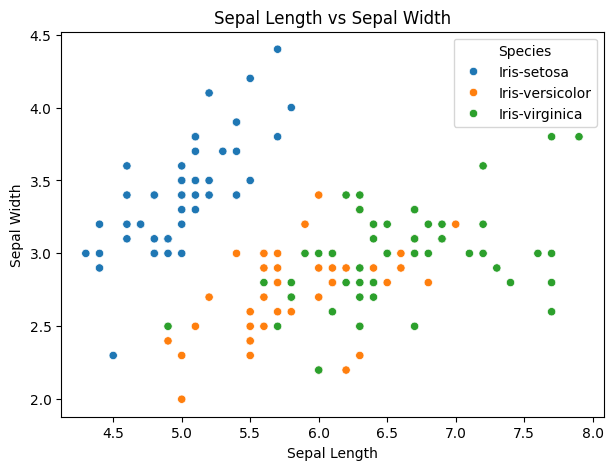

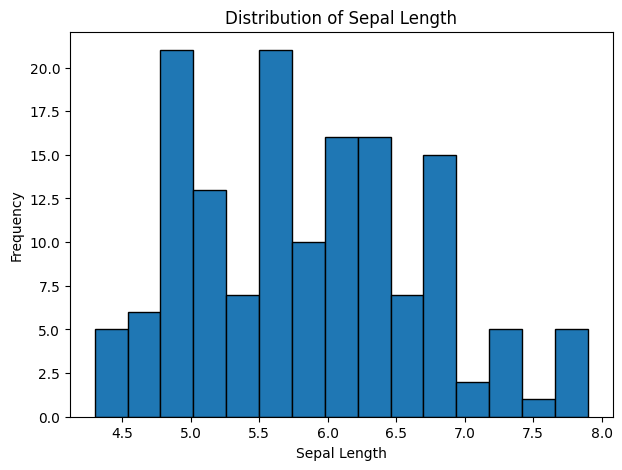

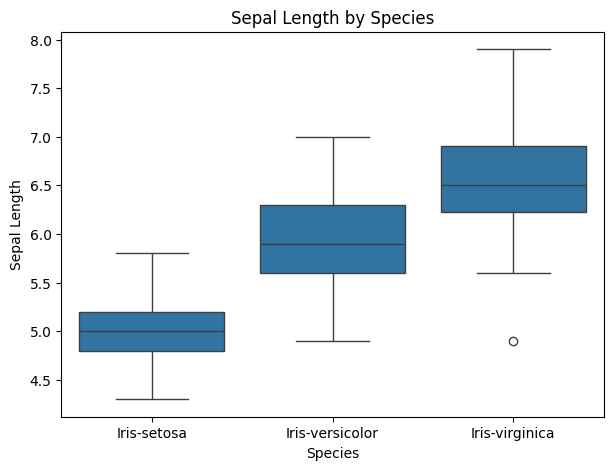

In [ ]:
#2) Scatter plot: Sepal Length vs Sepal Width
plt.figure(figsize=(7, 5))

sns.scatterplot(
    data=df,
    x="SepalLengthCm",
    y="SepalWidthCm",
    hue="Species"
)

plt.title("Sepal Length vs Sepal Width")
plt.xlabel("Sepal Length")
plt.ylabel("Sepal Width")
plt.show()


# Histogram of Sepal Length
plt.figure(figsize=(7, 5))

plt.hist(
    df["SepalLengthCm"],
    bins=15,
    edgecolor="black"
)

plt.title("Distribution of Sepal Length")
plt.xlabel("Sepal Length")
plt.ylabel("Frequency")
plt.show()


# Box plot of Sepal Length by Species
plt.figure(figsize=(7, 5))

sns.boxplot(
    data=df,
    x="Species",
    y="SepalLengthCm"
)

plt.title("Sepal Length by Species")
plt.xlabel("Species")
plt.ylabel("Sepal Length")
plt.show()



In [ ]:
#3) Select numerical features
X = df[
    [
        "SepalLengthCm",
        "SepalWidthCm",
        "PetalLengthCm",
        "PetalWidthCm"
    ]
]

# Target variable
y = df["Species"]


# 80:20 train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)


# Create Gaussian Naïve Bayes model
model = GaussianNB()


# Train the model
model.fit(X_train, y_train)


# Make predictions
y_pred = model.predict(X_test)



In [ ]:
#4)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy Percentage:", accuracy * 100, "%")


Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      0.90      0.95        10
 Iris-virginica       0.91      1.00      0.95        10

       accuracy                           0.97        30
      macro avg       0.97      0.97      0.97        30
   weighted avg       0.97      0.97      0.97        30

Accuracy: 0.9666666666666667
Accuracy Percentage: 96.66666666666667 %


# 11)Wine Quality Analysis and Naïve Bayes Classification
Using the Wine_Quality.csv dataset:
1. Perform basic EDA by displaying the first five records, missing values,
descriptive statistics, and quality distribution.
2. Plot a scatter plot of alcohol vs pH, a histogram of alcohol, and a box plot of
alcohol by quality.

3. Apply Gaussian Naïve Bayes to predict quality using the numerical features,
with an 80:20 train-test split.
# 4. Display the classification report and accuracy.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, accuracy_score


In [ ]:
df = pd.read_csv("/WineQT - WineQT.csv")

# Display first five records
print("First Five Records:")
print(df.head())


# Check missing values
print("\nMissing Values:")
print(df.isnull().sum())


# Descriptive statistics
print("\nDescriptive Statistics:")
print(df.describe())


# Quality distribution
print("\nQuality Distribution:")
print(df["quality"].value_counts().sort_index())



First Five Records:
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality  Id  
0      9.4        5   0  
1      9.8    

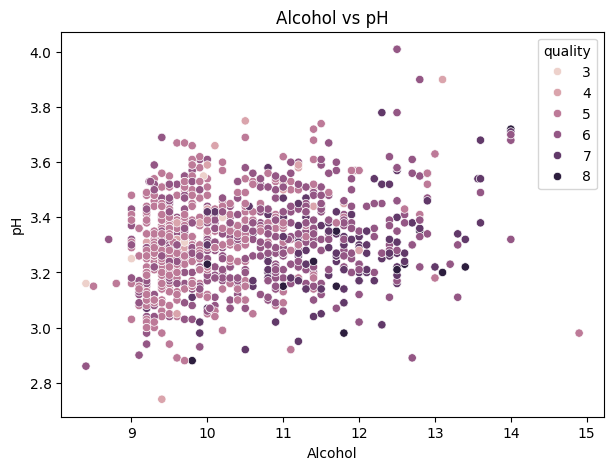

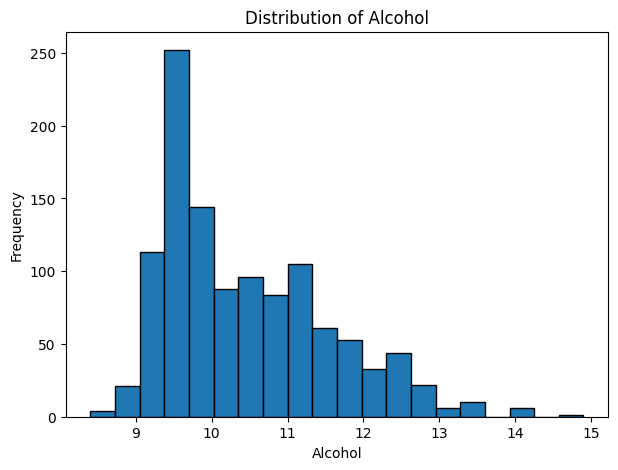

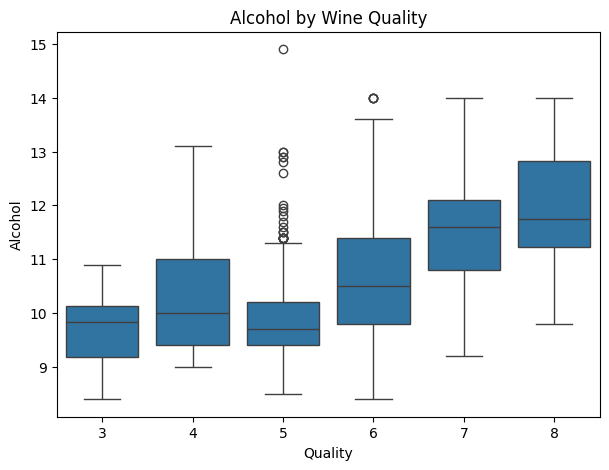

In [ ]:
# 2)Scatter plot: Alcohol vs pH
plt.figure(figsize=(7, 5))

sns.scatterplot(
    data=df,
    x="alcohol",
    y="pH",
    hue="quality"
)

plt.title("Alcohol vs pH")
plt.xlabel("Alcohol")
plt.ylabel("pH")
plt.show()


# Histogram of alcohol
plt.figure(figsize=(7, 5))

plt.hist(
    df["alcohol"],
    bins=20,
    edgecolor="black"
)

plt.title("Distribution of Alcohol")
plt.xlabel("Alcohol")
plt.ylabel("Frequency")
plt.show()


# Box plot of alcohol by quality
plt.figure(figsize=(7, 5))

sns.boxplot(
    data=df,
    x="quality",
    y="alcohol"
)

plt.title("Alcohol by Wine Quality")
plt.xlabel("Quality")
plt.ylabel("Alcohol")
plt.show()



In [ ]:
# 3)Remove missing values
df = df.dropna()

# Separate features and target
X = df.drop("quality", axis=1)

y = df["quality"]


# Select only numerical features
X = X.select_dtypes(include=["number"])


# 80:20 train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)


# Create Gaussian Naïve Bayes model
model = GaussianNB()


# Train the model
model.fit(X_train, y_train)


# Make predictions
y_pred = model.predict(X_test)

In [ ]:
#4)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy Percentage:", accuracy * 100, "%")


Classification Report:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.17      0.14      0.15         7
           5       0.72      0.60      0.65        97
           6       0.56      0.61      0.58        92
           7       0.33      0.34      0.34        29
           8       0.08      0.33      0.13         3

    accuracy                           0.55       229
   macro avg       0.31      0.34      0.31       229
weighted avg       0.58      0.55      0.56       229

Accuracy: 0.5502183406113537
Accuracy Percentage: 55.021834061135365 %


/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
